# Gaussian Sampling on a Semi-Infinite Domain

In [ ]:
from pathlib import Path
import sys
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import torch

notebook_dir = Path.cwd().resolve()
repo_root = next(
    (path for path in [notebook_dir, *notebook_dir.parents] if (path / "utils").is_dir()),
    notebook_dir,
)
utilities_dir = repo_root / "utils"
if str(utilities_dir) not in sys.path:
    sys.path.insert(0, str(utilities_dir))

import pinns_semi_infinite
import semi_infinite
reload(pinns_semi_infinite)
reload(semi_infinite)

from pinns_semi_infinite import build_models_KAN, set_seed
from semi_infinite import (
    analytical_solution_semi_inf,
    coefficient_semi_inf,
    evaluate_model_semi_inf,
    generate_dataset_semi_inf,
)

set_seed(42)
torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Generate Gaussian-exponential observations and evaluation data

In [ ]:
(
    X_obs,
    U_obs,
    X_obs_k,
    K_obs,
    X_pde,
    F_pde,
    X,
    Y,
    U,
    K,
) = generate_dataset_semi_inf(
    alpha=0.5,
    beta=5.0,
    epsilon=1.0,
    train_domain=(-5.0, 5.0, -5.0, 0.0),
    eval_domain=(-10.0, 10.0, -10.0, 0.0),
    sampling="gaussian_exponential",
    sigma=5.5,
    exp_scale=4.0,
    n_obs_u=100,
    n_boundary_u=10,
    n_obs_k=100,
    n_pde=1000,
    plot=False,
    device=device,
    seed=42,
)

boundary_mask = X_obs[:, 1] == 0
print(f"Interior u observations: {len(X_obs) - boundary_mask.sum().item()}")
print(f"Top-boundary u observations: {boundary_mask.sum().item()}")
print(f"Total u observations: {len(X_obs)}")

Interior u observations: 100
Top-boundary u observations: 10
Total u observations: 110


## Load the trained KAN models

In [ ]:
model_u, model_k = build_models_KAN(
    device=device,
    hidden_layers=3,
    hidden_units=25,
    grid_size=5,
    spline_order=3,
)

weights_path = repo_root / "main" / "03_individual_prediction" / "results" / "pikan_semi_infinite_tuned_weights.pt"
checkpoint = torch.load(weights_path, map_location=device)
model_u.load_state_dict(checkpoint["model_u"])
model_k.load_state_dict(checkpoint["model_k"])

<All keys matched successfully>

## Evaluate spatial generalization and create the figure

In [ ]:
results = evaluate_model_semi_inf(
    model_u=model_u,
    model_k=model_k,

    analytical_solution=analytical_solution_semi_inf,
    coefficient=coefficient_semi_inf,

    X_obs=X_obs,
    X_obs_k=X_obs_k,

    train_domain=(-5.0, 5.0, -5.0, 0.0),
    eval_domain=(-10.0, 10.0, -10.0, 0.0),
    n_grid=400,

    alpha=0.5,
    beta=5.0,
    epsilon=1.0,

    device=device,

    plot=False,
    verbose=True,
    save_results=False,
)

Semi-infinite-domain spatial generalization (MAE)
u (global): 3.755e-03
k (global): 8.758e-04
u (inside): 4.342e-03
k (inside): 8.316e-04
u (outside): 3.559e-03
k (outside): 8.905e-04


## Create the prediction, error, and MAE figure

Observed maxima: u error=0.0360, k error=0.0223
Manual color limits: u error=0.04, k error=0.02
Prediction/error plot saved to: /home/orincon/unbounded-domains/main/03_sampling_approximation/figures/exponential_semi_infinite_prediction_errors.pdf


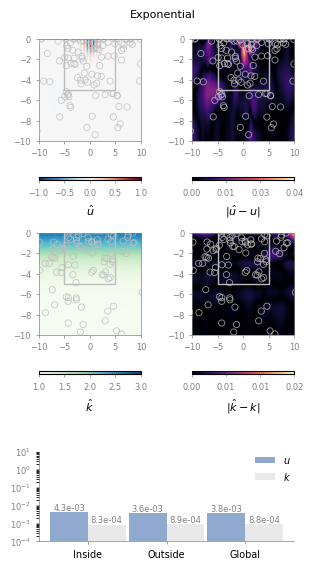

In [ ]:
train_xmin, train_xmax, train_ymin, train_ymax = (-5.0, 5.0, -5.0, 0.0)
eval_xmin, eval_xmax, eval_ymin, eval_ymax = (-10.0, 10.0, -10.0, 0.0)

U_pred = results["U_pred"]
K_pred = results["K_pred"]
error_u = results["error_u"]
error_k = results["error_k"]

# Set these manually to reuse identical color scales in the uniform notebook.
u_error_vmax = 0.04
k_error_vmax = 0.02
print(f"Observed maxima: u error={np.nanmax(error_u):.4f}, k error={np.nanmax(error_k):.4f}")
print(f"Manual color limits: u error={u_error_vmax:.2f}, k error={k_error_vmax:.2f}")

extent = [eval_xmin, eval_xmax, eval_ymin, eval_ymax]

fig = plt.figure(figsize=(3.3, 7.0))
grid = fig.add_gridspec(5, 2, height_ratios=[1.0, 0.08, 1.0, 0.42, 0.5], hspace=0.0, wspace=0.50)
ax_u, ax_u_error = fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])
ax_k, ax_k_error = fig.add_subplot(grid[2, 0]), fig.add_subplot(grid[2, 1])
ax_error = fig.add_subplot(grid[4, :])

images = [
    (ax_u, U_pred, "RdBu_r", -1, 1, r"$\hat{u}$"),
    (ax_u_error, error_u, "magma", 0, u_error_vmax, r"$|\hat{u}-u|$"),
    (ax_k, K_pred, "GnBu", 1, 3, r"$\hat{k}$"),
    (ax_k_error, error_k, "magma", 0, k_error_vmax, r"$|\hat{k}-k|$"),
]

for axis, field, cmap, vmin, vmax, colorbar_label in images:
    image = axis.imshow(field, extent=extent, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    axis.set_box_aspect(1)
    axis.set_xlim(eval_xmin, eval_xmax)
    axis.set_ylim(eval_ymin, eval_ymax)
    axis.add_patch(plt.Rectangle((train_xmin, train_ymin), train_xmax - train_xmin, train_ymax - train_ymin, fill=False, edgecolor="#BDBDBD", linewidth=1.0))
    colorbar = fig.colorbar(image, ax=axis, orientation="horizontal", fraction=0.028, pad=0.20, aspect=30)
    if axis is ax_k_error:
        k_ticks = np.linspace(0, k_error_vmax, 4)
        colorbar.set_ticks(k_ticks)
        colorbar.ax.set_xticklabels([f"{tick:.2f}" for tick in k_ticks])
    if axis is ax_u_error:
        u_ticks = np.linspace(0, u_error_vmax, 4)
        colorbar.set_ticks(u_ticks)
        colorbar.ax.set_xticklabels([f"{tick:.2f}" for tick in u_ticks])
    colorbar.set_label(colorbar_label, fontsize=8)
    colorbar.ax.tick_params(labelsize=6, length=2, width=0.5, colors="gray")

for axis, observations in ((ax_u, X_obs), (ax_u_error, X_obs), (ax_k, X_obs_k), (ax_k_error, X_obs_k)):
    points = observations.detach().cpu().numpy()
    axis.scatter(points[:, 0], points[:, 1], facecolors="none", edgecolors="#BDBDBD", s=20, alpha=0.8, linewidths=0.6, zorder=3)

boundary_points = X_obs[torch.isclose(X_obs[:, 1], torch.zeros_like(X_obs[:, 1]))].detach().cpu().numpy()
for axis in (ax_u, ax_u_error):
    axis.axhline(0.0, color="#2F80ED", linewidth=0.8, alpha=0.3, zorder=4)
    axis.scatter(boundary_points[:, 0], boundary_points[:, 1], facecolors="none", edgecolors="#BDBDBD", s=24, alpha=0.5, linewidths=0.8, zorder=5, label="top boundary samples")

regions = ["Inside", "Outside", "Global"]
u_errors = [results["err_u_inside"], results["err_u_outside"], results["err_u_global"]]
k_errors = [results["err_k_inside"], results["err_k_outside"], results["err_k_global"]]
positions = np.arange(len(regions))
width = 0.48
bars_u = ax_error.bar(positions - width / 2, u_errors, width=width, color="#2255a080", label=r"$u$")
bars_k = ax_error.bar(positions + width / 2, k_errors, width=width, color="#d6d6d683", label=r"$k$")
ax_error.set_yscale("log")
ax_error.set_ylim(1e-4, 10)
ax_error.set_xticks(positions)
ax_error.set_xticklabels(regions, fontsize=7, color="black")
ax_error.spines["top"].set_visible(False)
ax_error.spines["right"].set_visible(False)
ax_error.legend(fontsize=7, frameon=False, loc="upper right", ncol=1, borderaxespad=0)
for bar, value in zip([*bars_u, *bars_k], [*u_errors, *k_errors]):
    ax_error.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.1e}", ha="center", va="bottom", fontsize=6, color="gray")

axis_color = "gray"
for axis in (ax_u, ax_u_error, ax_k, ax_k_error, ax_error):
    axis.tick_params(axis="both", labelsize=6, colors=axis_color, length=2, width=0.5)
    for spine in axis.spines.values():
        spine.set_color(axis_color)
        spine.set_linewidth(0.5)

# Keep the region labels black
ax_error.set_xticklabels(
    regions,
    fontsize=7,
    color="black",
)

fig.suptitle("Exponential", fontsize=8, y=0.87)
plot_path = repo_root / "main" / "03_sampling_approximation" / "figures" / "exponential_semi_infinite_prediction_errors.pdf"
plot_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Prediction/error plot saved to: {plot_path}")
plt.show()